In [138]:
import numpy as np
import cv2
from PIL import Image
def get_bottom_middle_coords(contours, label):
    bottom_coords = []
    for contour in contours:
        contour = contour.squeeze()
        if contour.ndim != 2:
            continue
        # Find the bottom-most point(s)
        max_y = np.max(contour[:, 1])
        bottom_points = contour[contour[:, 1] == max_y]
        # Calculate the middle x of bottom points
        middle_x = int(np.mean(bottom_points[:, 0]))
        bottom_coords.append({
            "class": label,
            "bottom_middle_coordinate": (middle_x, int(max_y))
        })
    return bottom_coords
def obj_coords(img):
    image_path = img
    Image.MAX_IMAGE_PIXELS = None
    img = Image.open(image_path)
    width, height = img.size
    width = int(width / 2)
    height = int(height /2)
    img = img.resize((width, height), Image.Resampling.LANCZOS)
    image_np = np.array(img)

    # Convert image to grayscale mask to identify regions
    # Define color ranges for red and green in BGR format
    red_lower = np.array([0, 0, 128])
    red_upper = np.array([100, 100, 255])
    green_lower = np.array([0, 128, 0])
    green_upper = np.array([100, 255, 100])

    # Convert the image from RGB to BGR for OpenCV processing
    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Create masks
    red_mask = cv2.inRange(image_bgr, red_lower, red_upper)
    green_mask = cv2.inRange(image_bgr, green_lower, green_upper)

    # Find contours for red and green areas
    red_contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    green_contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Prepare data for output
    object_data = []

    # Get bottom-middle coordinates for both classes
    red_bottom_coords = get_bottom_middle_coords(red_contours, "red")
    green_bottom_coords = get_bottom_middle_coords(green_contours, "green")

    # Combine and display
    bottom_coords_data = red_bottom_coords + green_bottom_coords
    return bottom_coords_data

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin, cos, radians, atan2, degrees
import matplotlib.cm as cm
def compute_object_gps(lat_d, lon_d, yaw_deg, pitch_deg, roll_deg, pixel_x, pixel_y, height_agl,
                       f_mm=6.7, sensor_width_mm=10, sensor_height_mm=7.5,
                       image_width_px=8064, image_height_px=6048):
    
    # Umrechnung in metrische Einheiten
    f_m = f_mm / 1000
    sensor_width_m = sensor_width_mm / 1000
    sensor_height_m = sensor_height_mm / 1000

    px_size_x = sensor_width_m / image_width_px
    px_size_y = sensor_height_m / image_height_px

    cx = image_width_px / 2
    cy = image_height_px / 2

    x_sensor = (pixel_x - cx) * px_size_x
    y_sensor = (pixel_y - cy) * px_size_y

    v_cam = np.array([x_sensor, -y_sensor, f_m])
    v_cam = v_cam / np.linalg.norm(v_cam)

    def rotation_matrix(yaw, pitch, roll):
        yaw = radians(yaw)
        pitch = radians(pitch)
        roll = radians(roll)

        R_yaw = np.array([
            [cos(yaw), -sin(yaw), 0],
            [sin(yaw), cos(yaw), 0],
            [0, 0, 1]
        ])
        R_pitch = np.array([
            [cos(pitch), 0, sin(pitch)],
            [0, 1, 0],
            [-sin(pitch), 0, cos(pitch)]
        ])
        R_roll = np.array([
            [1, 0, 0],
            [0, cos(roll), -sin(roll)],
            [0, sin(roll), cos(roll)]
        ])
        return R_yaw @ R_pitch @ R_roll

    R = rotation_matrix(yaw_deg, pitch_deg, roll_deg)
    v_world = R @ v_cam

    P_drone = np.array([0, 0, height_agl])
    t = -P_drone[2] / v_world[2]
    P_object = P_drone + t * v_world

    delta_north = P_object[1]
    delta_east = P_object[0]
    

    delta_lat = delta_north / 110574
    delta_lon = delta_east / (111320 * cos(radians(lat_d)))

    lat_obj = lat_d + delta_lat
    lon_obj = lon_d + delta_lon

    return lat_obj, lon_obj

In [140]:
import matplotlib.pyplot as plt
def plot_objects_on_map(objects,height, lat_d, lon_d, yaw, pitch, roll):
    latitudes = []
    longitudes = []
    labels = []

    for obj in objects:
        label = obj['class']
        x, y = obj['bottom_middle_coordinate']
        lat, lon, calc_yaw = compute_object_gps(lat_d, lon_d, yaw, pitch, roll, x, y, height)
        latitudes.append(lat)
        longitudes.append(lon)
        labels.append(label)

    # Farben je Klasse
    unique_labels = list(set(labels))
    colormap = cm.get_cmap('tab10', len(unique_labels))
    label_to_color = {label: colormap(i) for i, label in enumerate(unique_labels)}

    # Plot
    plt.figure(figsize=(10, 8))
    for lat, lon, label in zip(latitudes, longitudes, labels):
        plt.scatter(lon, lat, color=label_to_color[label], label=label, s=50)
    plt.scatter(lon_d, lat_d, color="red")
    # Legende ohne Wiederholung
    handles, lbls = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    plt.legend(by_label.values(), by_label.keys())

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Detected Object Positions")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

In [141]:
import subprocess
import json
def read_dji_metadata(dng_path):
    # Run exiftool with JSON output
    result = subprocess.run(["exiftool", "-n", "-j", dng_path],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        raise Exception("ExifTool error:\n" + result.stderr)

    metadata = json.loads(result.stdout)[0]
    # Extract relevant fields (fallback to None if missing)
    gps_lat = float(metadata.get("GPSLatitude"))
    gps_lon = float(metadata.get("GPSLongitude"))
    gps_alt = -1*float(metadata.get("AbsoluteAltitude"))+10

    # DJI-specific fields
    #pitch = float(metadata.get("FlightPitchDegree"))
    pitch = -23.9
    roll = float(metadata.get("FlightRollDegree"))
    yaw = float(metadata.get("FlightYawDegree"))
    yaw = (90 - yaw) % 360

    return gps_lat, gps_lon, yaw, pitch, roll, gps_alt

In [142]:
import numpy as np
from math import sin, cos, radians, atan2, degrees
import matplotlib.pyplot as plt
import os
indir = "/Users/filiprothaut/Downloads/masken/filled"
dng_path = "/Volumes/Untitled/DCIM/100MEDIA"
dngs= [file for file in os.listdir(dng_path) if file.endswith('.DNG')]
imgs = os.listdir(indir)


In [154]:
from collections import defaultdict
labeled_coords = defaultdict(list)
droneobjs = {}
imageobjs = {}
for filename in imgs:
    if filename.endswith(".png"):
        num = filename.split("_")[1]
        objects_in_image = obj_coords(os.path.join(indir, filename))
        dng = [f for f in dngs if num in f][0]
        lat_d, lon_d, yaw_deg, pitch_deg, roll_deg,height_agl = read_dji_metadata(os.path.join(dng_path, dng))
        objects_coords = []
        for obj in objects_in_image:
            label = obj['class']
            x, y = obj['bottom_middle_coordinate']
            lat, lon = compute_object_gps(lat_d, lon_d, yaw_deg, pitch_deg, roll_deg, x, y, height_agl)
            labeled_coords[label].append((lat, lon))
        imageobjs[num] = labeled_coords
        droneobjs[num] = lat_d, lon_d
        #plot_objects_on_map(objects_in_image, height_agl, lat_d, lon_d, yaw_deg, pitch_deg, roll_deg)
print(imageobjs)



{'0548': defaultdict(<class 'list'>, {'red': [(44.501704138145, 1.0747017318383658), (44.50178969830121, 1.074675542720255), (44.50168268634991, 1.0746755653376627), (44.50172879067485, 1.074662296539412), (44.50175527077725, 1.0746643086686574), (44.501780874261726, 1.0746653288154746), (44.50163937344465, 1.0746596096212717), (44.501751876455614, 1.074657030938537), (44.50174701045883, 1.0746515100496814), (44.501769883212745, 1.0746576270959305), (44.50172433291897, 1.0746434304290917), (44.50173096670793, 1.0746394290892793), (44.5016986335102, 1.074636742172143), (44.501601650845565, 1.0746170324722417), (44.5016255635553, 1.0746153148194328), (44.501688502802416, 1.0747397334355253), (44.50172300023515, 1.0746981336528958), (44.50162149071079, 1.0747062796648772), (44.501648205206784, 1.0747035529769833), (44.50171000443403, 1.074681047307852), (44.501609833905675, 1.0746833218133713), (44.501730961899376, 1.0746698517502697), (44.50162202861323, 1.0746659579282103), (44.50170054

In [155]:
with open('webapp/js/points.json', 'w') as f:
    json.dump(imageobjs, f, indent=2)

{'0548': [], '0549': [], '0554': [], '0560': [], '0552': [], '0553': [], '0566': [], '0567': [], '0558': [], '0545': [], '0563': [], '0568': [], '0556': [], '0557': [], '0448': [], '0546': [], '0564': [], '0551': [], '0550': []}


/var/folders/8q/bws08zmn4l5g0z8rnn85mh8w0000gn/T/ipykernel_53215/660539117.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab10', len(unique_labels))


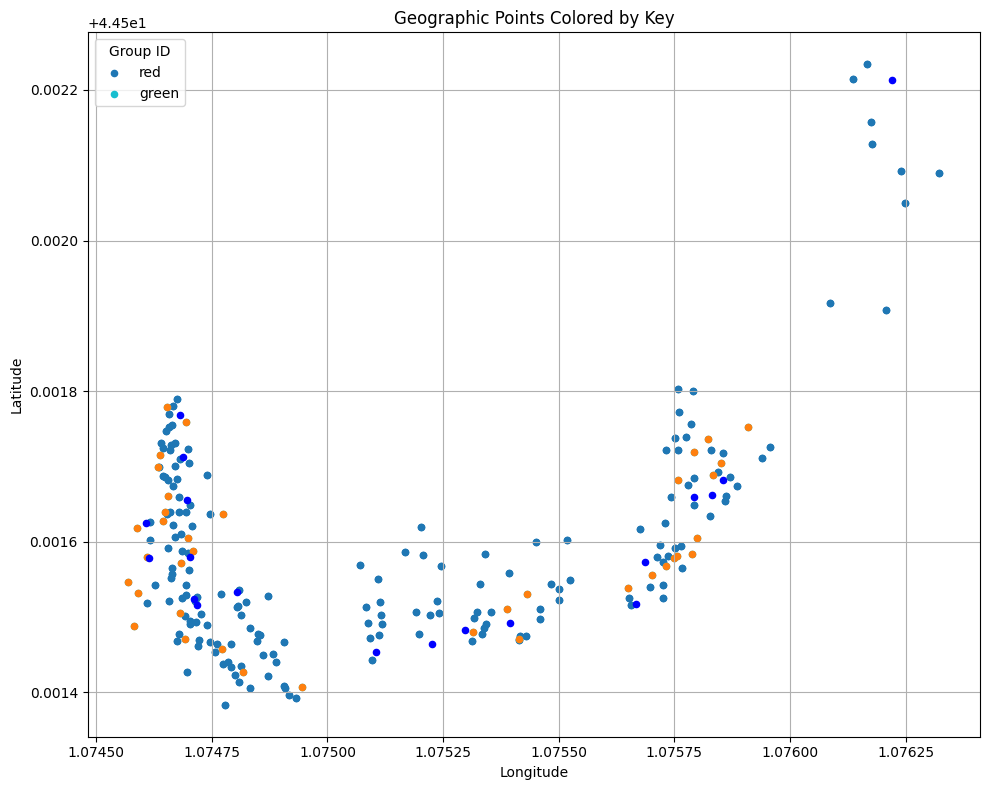

In [153]:
# Create a plot
unique_labels = list(labeled_coords.keys())
colors = cm.get_cmap('tab10', len(unique_labels))
label_color_map = {label: colors(i) for i, label in enumerate(unique_labels)}

plt.figure(figsize=(10, 8))
print(imageobjs)
# Plot each group with a unique color and label
for label, coords in labeled_coords.items():
    lats, lons = zip(*coords)
    plt.scatter(lons, lats, color=label_color_map[label], label=label, s=20)
    plt.scatter(lons, lats, s=20)  # s=20 sets the marker size
for key, coordinates in droneobjs.items():
    lats,lons = coordinates
    plt.scatter(lons, lats, color="blue", s=20)
# Add labels and legend
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Points Colored by Key')
plt.legend(title="Group ID")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_objectinimage(lat_d, lon_d, yaw, pitch, roll, objx, objy):
    # === Parameter ===
    f_mm = 24  # Brennweite in mm
    sensor_width_mm = 10
    sensor_height_mm = 7.5
    image_width_px = 8064
    image_height_px = 6048
    pixel_x = 4100
    pixel_y = 3600

    # Drohnenposition und Orientierung
    lat_d, lon_d = 44.501523, 1.07471
    height_agl = 2.518  # Meter über Boden
    yaw_deg = 178
    pitch_deg = 47
    roll_deg = 3.2
    # === Umrechnung in metrische Einheiten ===
    f_m = f_mm / 1000
    sensor_width_m = sensor_width_mm / 1000
    sensor_height_m = sensor_height_mm / 1000

    px_size_x = sensor_width_m / image_width_px
    px_size_y = sensor_height_m / image_height_px

    cx = image_width_px / 2
    cy = image_height_px / 2

    # === Pixel -> Sensor ===
    x_sensor = (pixel_x - cx) * px_size_x
    y_sensor = (pixel_y - cy) * px_size_y

    # === Richtungsvektor im Kamerakoordinatensystem ===
    v_cam = np.array([x_sensor, -y_sensor, f_m])
    v_cam = v_cam / np.linalg.norm(v_cam)

    # === Rotationsmatrix ===
    def rotation_matrix(yaw, pitch, roll):
        yaw = radians(yaw)
        pitch = radians(pitch)
        roll = radians(roll)

        R_yaw = np.array([
            [cos(yaw), -sin(yaw), 0],
            [sin(yaw), cos(yaw), 0],
            [0, 0, 1]
        ])
        R_pitch = np.array([
            [cos(pitch), 0, sin(pitch)],
            [0, 1, 0],
            [-sin(pitch), 0, cos(pitch)]
        ])
        R_roll = np.array([
            [1, 0, 0],
            [0, cos(roll), -sin(roll)],
            [0, sin(roll), cos(roll)]
        ])
        return R_yaw @ R_pitch @ R_roll

    R = rotation_matrix(yaw_deg, pitch_deg, roll_deg)
    v_world = R @ v_cam

    # === Positionen ===
    P_drone = np.array([0, 0, height_agl])
    t = -P_drone[2] / v_world[2]
    P_object = P_drone + t * v_world

    # === GPS-Koordinaten berechnen ===
    delta_north = P_object[1]
    delta_east = P_object[0]

    delta_lat = delta_north / 110574
    delta_lon = delta_east / (111320 * cos(radians(lat_d)))

    lat_obj = lat_d + delta_lat
    lon_obj = lon_d + delta_lon

    # === Berechne Richtung (Yaw) in Grad von Norden (bearing) ===
    def azimuth(east, north):
        bearing_rad = atan2(east, north)
        bearing_deg = (degrees(bearing_rad) + 360) % 360
        return bearing_deg

    calculated_yaw = azimuth(delta_east, delta_north)

    # === Ergebnisse ===
    print("GPS des Objekts:")
    print(f"Lat: {lat_obj:.8f}, Lon: {lon_obj:.8f}")
    print("Position relativ zur Drohne (in Meter):", P_object)
    print(f"Berechneter Yaw (von Norden aus): {calculated_yaw:.2f}°")


GPS des Objekts:
Lat: 44.50151927, Lon: 1.07474409
Position relativ zur Drohne (in Meter): [ 2.70662364 -0.41274418  0.        ]
Berechneter Yaw (von Norden aus): 98.67°


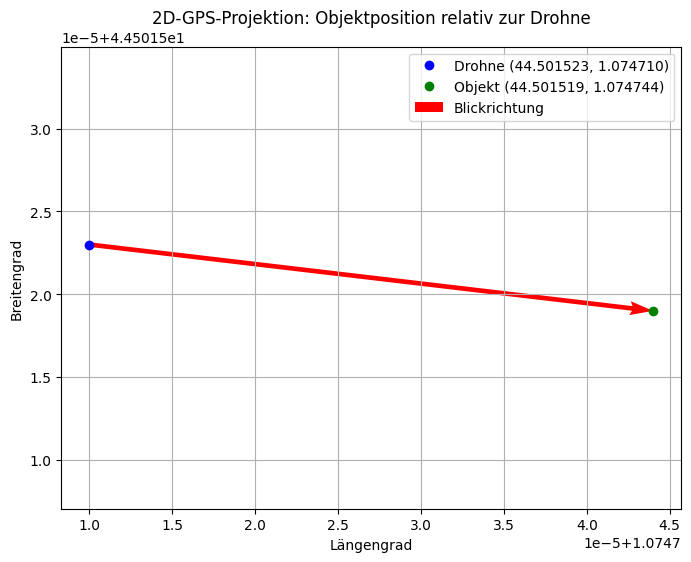

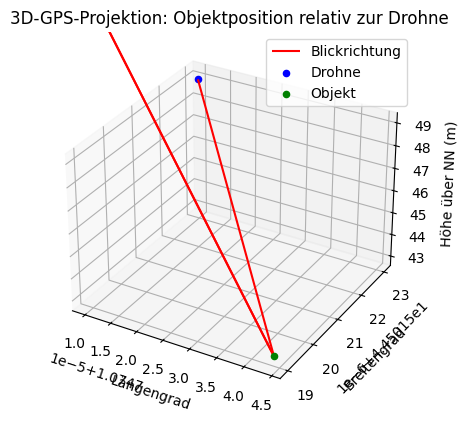

In [6]:

# === Plots ===
lat_d_str = f"{lat_d:.6f}"
lon_d_str = f"{lon_d:.6f}"
lat_obj_str = f"{lat_obj:.6f}"
lon_obj_str = f"{lon_obj:.6f}"

# 2D-Plot
plt.figure(figsize=(8, 6))
plt.plot(float(lon_d_str), float(lat_d_str), 'bo', label=f'Drohne ({lat_d_str}, {lon_d_str})')
plt.plot(float(lon_obj_str), float(lat_obj_str), 'go', label=f'Objekt ({lat_obj_str}, {lon_obj_str})')
plt.quiver(float(lon_d_str), float(lat_d_str),
           float(lon_obj_str) - float(lon_d_str),
           float(lat_obj_str) - float(lat_d_str),
           angles='xy', scale_units='xy', scale=1,
           color='red', label='Blickrichtung')

plt.xlabel("Längengrad")
plt.ylabel("Breitengrad")
plt.title("2D-GPS-Projektion: Objektposition relativ zur Drohne")
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

# 3D-Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.quiver(float(lon_d_str), float(lat_d_str), 49,
          float(lon_obj_str) - float(lon_d_str),
          float(lat_obj_str) - float(lat_d_str),
          -6,
          length=1.0, normalize=False, color='r', label='Blickrichtung')
ax.scatter(float(lon_d_str), float(lat_d_str), 49, color='blue', label='Drohne')
ax.scatter(float(lon_obj_str), float(lat_obj_str), 43, color='green', label='Objekt')

ax.set_xlabel("Längengrad")
ax.set_ylabel("Breitengrad")
ax.set_zlabel("Höhe über NN (m)")
ax.set_title("3D-GPS-Projektion: Objektposition relativ zur Drohne")
ax.legend()
plt.show()